In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Import market data from saved csv files, clean, and visualize
# Limited dataset: Choose pre-live tournamnet (Monday 12am to Thursday 5am EST) data for the following events:
# - RBH26: RBC Heritage 2026 (April 13 - April 16, 2026)
# - CAC26: Cadillac Championship 2026 (April 27 - April 30, 2026)
# - TRC26: Truist Championship 2026 (May 4 - May 7, 2026)
# - PGC26: PGA Championship 2026 (May 11 - May 14, 2026)

# Choose pre-live tournamnet (Monday 12am to Thursday 5am EST) data for the following markets:
# - KXPGATOUR - Tournament Winner (Market ID starts with 'KXPGATOUR-TRC26' for example)
# - KXPGATOP10 - Top 10 Finish (Market ID starts with 'KXPGATOP10-TRC26' for example)

event = 'TRC26'
market_type = 'KXPGATOP10'  # Top 10 Finish market type
series_prefix = f'{market_type}-{event}'  # Series prefix from event
contract_start_date_str = '2026-05-04'
event_start_date_str = '2026-05-07'

market_data = pd.read_csv(f'kalshi_golf_trades_{series_prefix}_{contract_start_date_str}_{event_start_date_str}.csv')

# Extract the name from the market title, which is in the format "Will [Player Name]..."
if market_type == 'KXPGATOUR':
    title_format = r'Will (.*?) win'
elif market_type == 'KXPGATOP10':
    title_format = r'Will (.*?) finish top 10'
market_data['player_name'] = market_data['title'].str.extract(title_format)[0]

print(market_data.to_string(max_rows=5))

      count_fp                 created_time  no_price_dollars taker_book_side taker_outcome_side taker_side                 ticker                              trade_id  yes_price_dollars                                                     title      player_name
0        29.00  2026-05-04T20:58:10.263117Z              0.75             ask                 no         no  KXPGATOP10-TRC26-ASCO  f9e43a0f-eb63-6339-3a29-fbb6bb9f9efe               0.25       Truist Championship: Will Adam Scott finish top 10?       Adam Scott
1        35.00  2026-05-04T21:03:47.445905Z              0.82             ask                 no         no  KXPGATOP10-TRC26-WKIM  1350a859-485a-6e9e-2595-a6bc79ef5c4a               0.18       Truist Championship: Will Si Woo Kim finish top 10?       Si Woo Kim
...        ...                          ...               ...             ...                ...        ...                    ...                                   ...                ...                        

In [3]:
# Calculate summary statistics by ticker
print("\n=== SUMMARY STATISTICS BY TICKER ===")
summary = market_data.groupby('player_name').agg(
    total_trades=('ticker', 'count'),
    avg_yes_price=('yes_price_dollars', lambda x: x.astype(float).mean()),
    avg_no_price=('no_price_dollars', lambda x: x.astype(float).mean()),
    total_shares_traded=('count_fp', lambda x: x.astype(float).sum()),
    yes_price_stddev=('yes_price_dollars', lambda x: x.astype(float).std()),
    no_price_stddev=('no_price_dollars', lambda x: x.astype(float).std())
).reset_index()

# Sort by total shares traded or volatility descending
# summary = summary.sort_values(by='yes_price_stddev', ascending=False)
summary = summary.sort_values(by='total_shares_traded', ascending=False)

print(summary.to_string(index=False))

# Send summary to csv
# summary.to_csv('kalshi_golf_trades_summary_' + series_prefix + '_' + contract_start_date_str + '_' + event_start_date_str + '.csv', index=False)


=== SUMMARY STATISTICS BY TICKER ===
          player_name  total_trades  avg_yes_price  avg_no_price  total_shares_traded  yes_price_stddev  no_price_stddev
         Rory McIlroy           165       0.549576      0.450424             30582.83          0.010082     1.008207e-02
    Xander Schauffele           174       0.465115      0.534885             19307.03          0.006337     6.337201e-03
         Ludvig Aberg           147       0.360204      0.639796             14377.12          0.003199     3.198756e-03
        Cameron Young           176       0.481534      0.518466             14141.94          0.015210     1.521011e-02
     Hideki Matsuyama            16       0.237500      0.762500              8985.24          0.008563     8.563488e-03
     Matt Fitzpatrick           121       0.381570      0.618430              8734.34          0.003875     3.874761e-03
      Tommy Fleetwood            49       0.301429      0.698571              5563.99          0.007071     7.07106

(array([20578.  , 20578.25, 20578.5 , 20578.75, 20579.  , 20579.25,
        20579.5 , 20579.75, 20580.  , 20580.25]),
 [Text(20578.0, 0, '05-05 00'),
  Text(20578.25, 0, '05-05 06'),
  Text(20578.5, 0, '05-05 12'),
  Text(20578.75, 0, '05-05 18'),
  Text(20579.0, 0, '05-06 00'),
  Text(20579.25, 0, '05-06 06'),
  Text(20579.5, 0, '05-06 12'),
  Text(20579.75, 0, '05-06 18'),
  Text(20580.0, 0, '05-07 00'),
  Text(20580.25, 0, '05-07 06')])

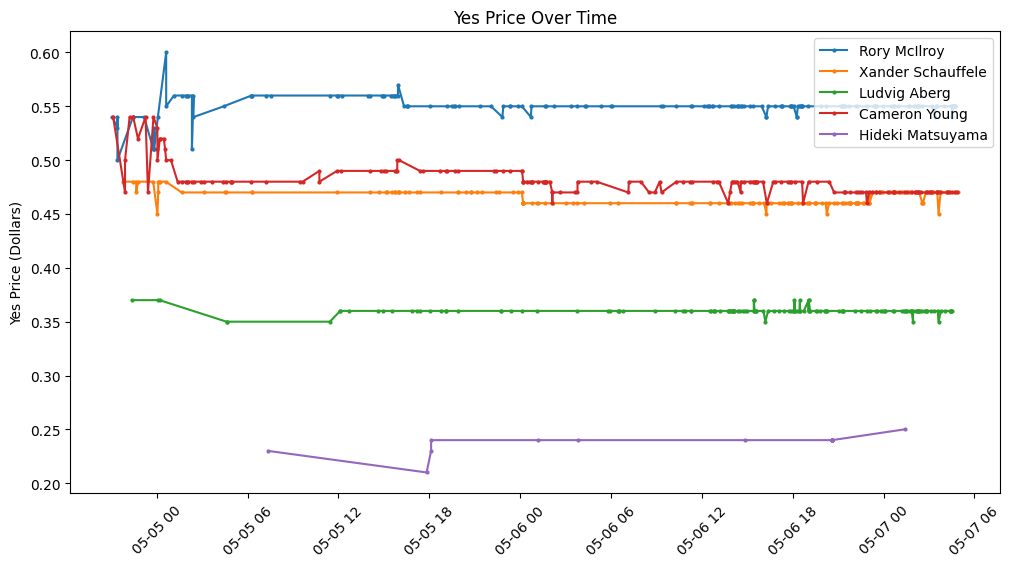

In [4]:
# Create a line graph of yes_price_dollars with different lines for each market title using top 5 markets by total shares traded
# Make line markers different on each line depending on if taker_book_side is bid or ask (e.g. circle for bid, square for ask)
num_players = 5
top_markets = summary.head(num_players)['player_name'].tolist()

plt.figure(figsize=(12, 6))
for player_name in top_markets:
        player_data = market_data[market_data['player_name'] == player_name].copy()
        player_data['created_time'] = pd.to_datetime(player_data['created_time'], unit='ms')
        player_data = player_data.sort_values('created_time')
        plt.plot(player_data['created_time'], player_data['yes_price_dollars'].astype(float), label=player_name, marker='o', markersize=2)
plt.ylabel('Yes Price (Dollars)')
plt.title('Yes Price Over Time')
plt.legend(loc='upper right')
plt.xticks(rotation=45)


=== BID vs ASK COUNTS FOR TOP MARKETS ===
taker_book_side    ask  bid
player_name                
Cameron Young       19  157
Hideki Matsuyama     1   15
Ludvig Aberg         3  144
Rory McIlroy        15  150
Xander Schauffele   10  164


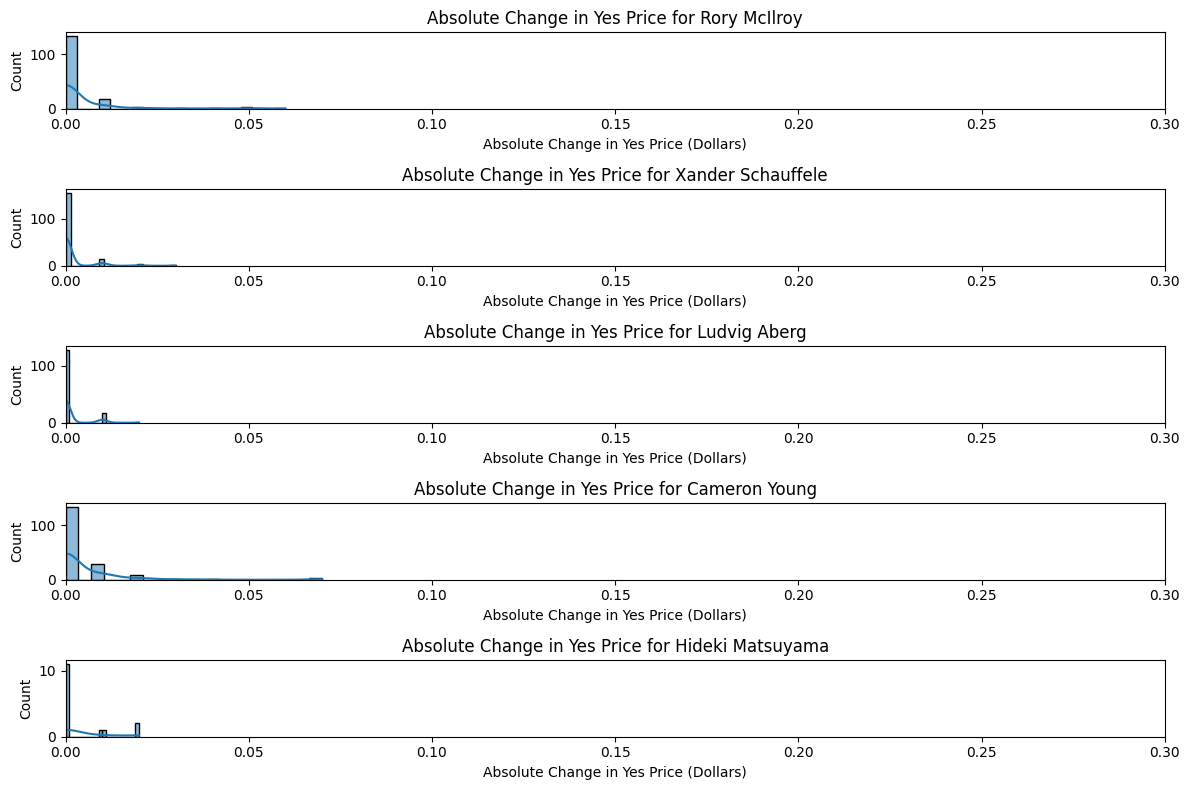

In [5]:
# Find approximate distribution of bid vs ask trades for marker shapes
bid_ask_counts = market_data[market_data['player_name'].isin(top_markets)].groupby(['player_name', 'taker_book_side']).size().unstack(fill_value=0)
print("\n=== BID vs ASK COUNTS FOR TOP MARKETS ===")
print(bid_ask_counts)

# Create individual histograms of absolute changes yes_price_dollars for all trades by market title- using top 5 markets by total shares traded
# Box the charts by market title and make the x-axis the same for all charts to compare distributions across markets
plt.figure(figsize=(12, 8))
for i, player_name in enumerate(top_markets):
    player_data = market_data[market_data['player_name'] == player_name].copy()
    player_data['yes_price_dollars'] = player_data['yes_price_dollars'].astype(float)
    player_data['yes_price_change'] = player_data['yes_price_dollars'].diff().abs()
    
    plt.subplot(num_players, 1, i + 1)
    sns.histplot(player_data['yes_price_change'].dropna(), bins=20, kde=True)
    plt.title(f'Absolute Change in Yes Price for {player_name}')
    plt.xlabel('Absolute Change in Yes Price (Dollars)')
    plt.xlim(0, market_data['yes_price_dollars'].astype(float).max() * 0.5)  # Set x-axis limit to focus on smaller changes
    plt.tight_layout()


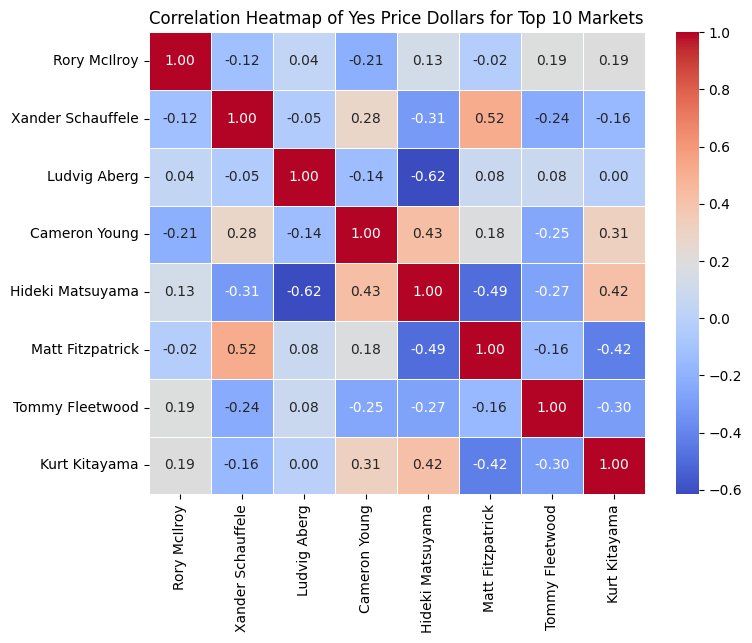

In [9]:
# Calculate correlation between yes_price_dollars across the top 10 markets by total shares traded
top_markets = summary.head(8)['player_name'].tolist()
correlation_matrix = pd.DataFrame()
for title in top_markets:
    player_data = market_data[market_data['player_name'] == title].copy()
    player_data['created_time'] = pd.to_datetime(player_data['created_time'], unit='ms')
    player_data = player_data.sort_values('created_time')
    correlation_matrix[title] = player_data['yes_price_dollars'].astype(float).reset_index(drop=True)
correlation_matrix = correlation_matrix.corr()

# Make correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Yes Price Dollars for Top 10 Markets')
plt.show()

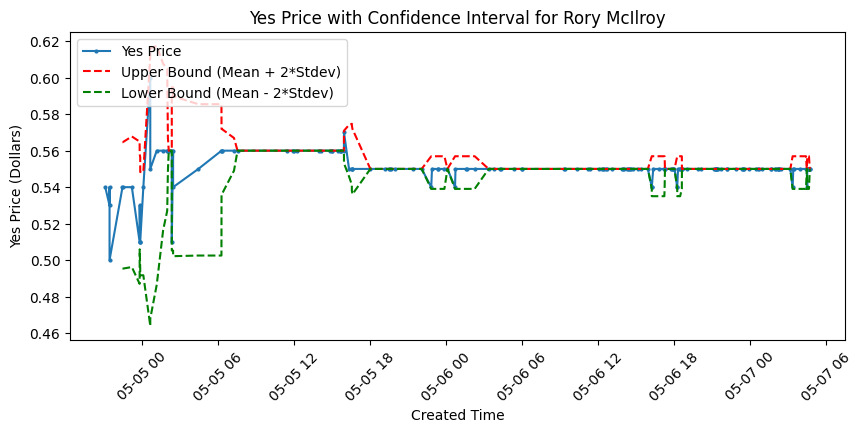

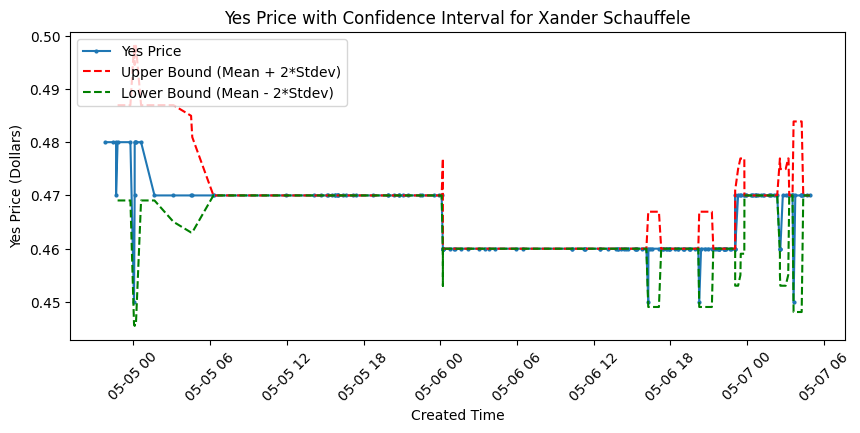

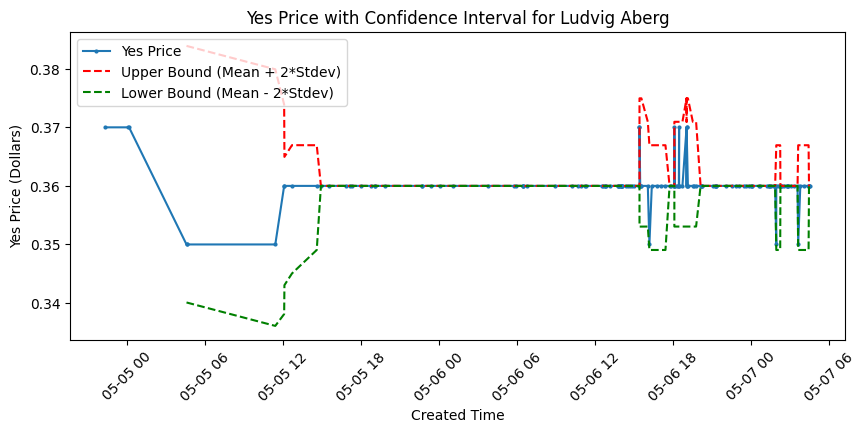

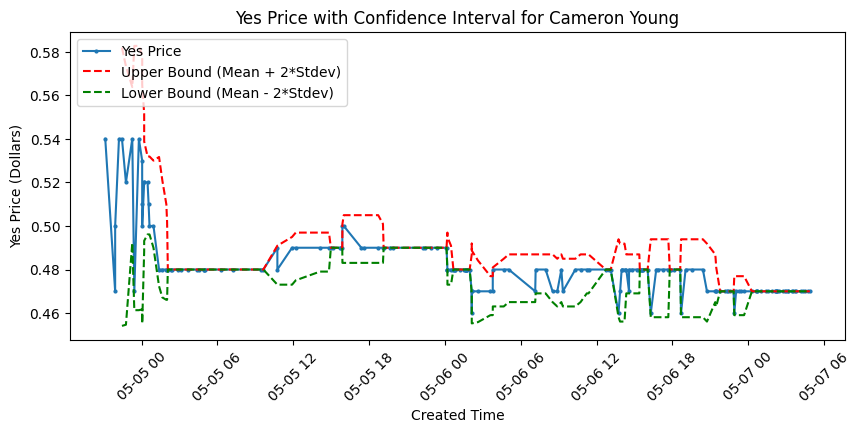

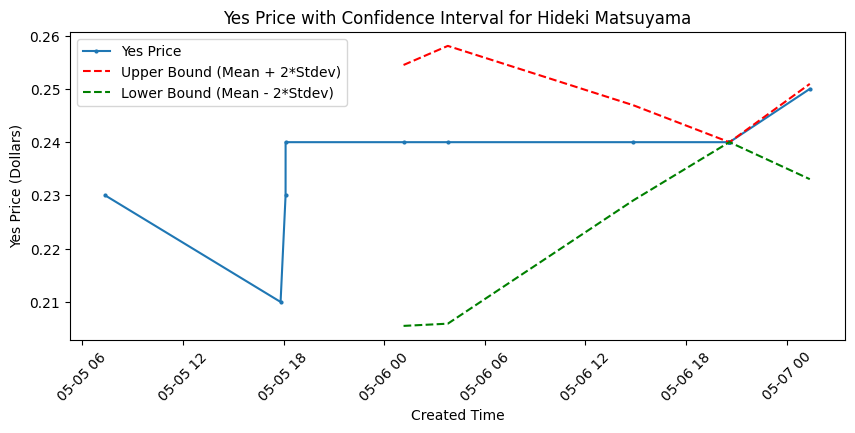

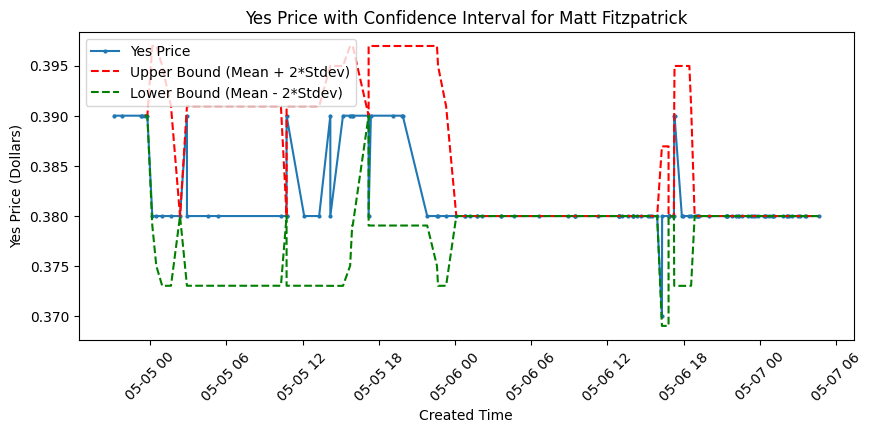

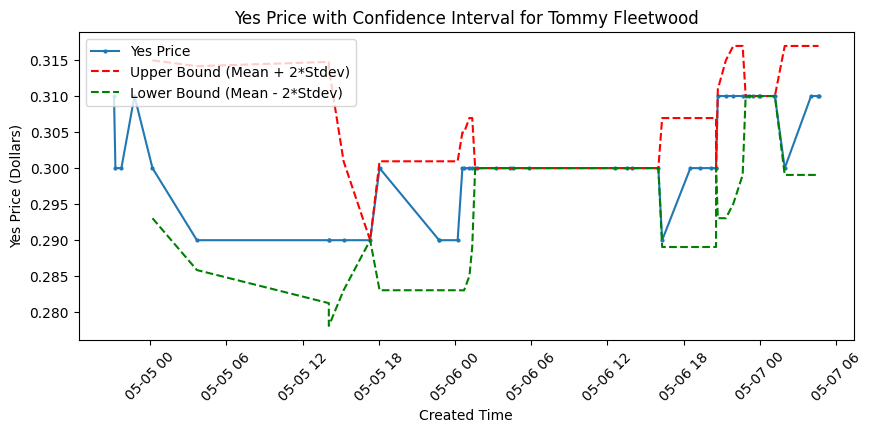

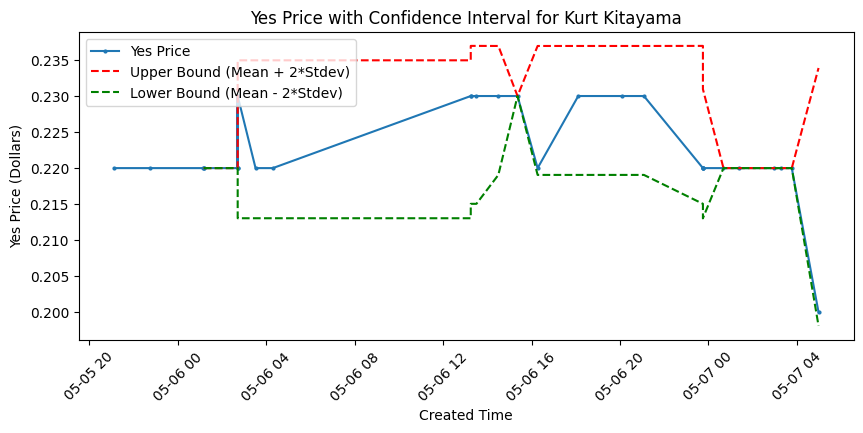

In [10]:
# Use yes_dollar_stdev to create a moving confidence interval and identify any significant price movements outside of this interval (e.g. >2 standard deviations from the mean) and plot these against created_time for each market
threshold = 2  # number of standard deviations for confidence interval; i.e. 95% confidence interval would be mean +/-2 standard deviations
# Likely display lognormal distribution
for title in top_markets:
    player_data = market_data[market_data['player_name'] == title].copy()
    player_data['created_time'] = pd.to_datetime(player_data['created_time'], unit='ms')
    player_data = player_data.sort_values('created_time')
    player_data['yes_price_dollars'] = player_data['yes_price_dollars'].astype(float)
    player_data['yes_price_stdev'] = player_data['yes_price_dollars'].rolling(window=5).std()  # 5-trade rolling standard deviation
    player_data['yes_price_mean'] = player_data['yes_price_dollars'].rolling(window=5).mean()  # 5-trade rolling mean
    player_data['upper_bound'] = player_data['yes_price_mean'] + threshold * player_data['yes_price_stdev']
    player_data['lower_bound'] = player_data['yes_price_mean'] - threshold * player_data['yes_price_stdev']
    
    plt.figure(figsize=(10, 4))
    plt.plot(player_data['created_time'], player_data['yes_price_dollars'], label='Yes Price', marker='o', markersize=2)
    plt.plot(player_data['created_time'], player_data['upper_bound'], label='Upper Bound (Mean + 2*Stdev)', linestyle='--', color='red')
    plt.plot(player_data['created_time'], player_data['lower_bound'], label='Lower Bound (Mean - 2*Stdev)', linestyle='--', color='green')
    plt.title(f'Yes Price with Confidence Interval for {title}', wrap=True)
    plt.xlabel('Created Time')
    plt.ylabel('Yes Price (Dollars)')
    plt.legend(loc='upper left')
    plt.xticks(rotation=45)
    plt.show()


=== STOIKOV MODEL OPTIMAL QUOTES ===

           Player Mid Price Optimal Bid Optimal Ask Spread Volatility Bid Volume Ask Volume  Inventory
     Rory McIlroy    $0.550      $0.545      $0.555 $0.010     2.1798      30260        323          0
Xander Schauffele    $0.470      $0.465      $0.475 $0.010     5.1658      16398       2909          0
     Ludvig Aberg    $0.360      $0.355      $0.365 $0.010     3.3465      14300         77          0
    Cameron Young    $0.470      $0.465      $0.475 $0.010     0.0000      12018       2124          0
 Hideki Matsuyama    $0.250      $0.245      $0.255 $0.010     3.2531       8984          1          0
 Matt Fitzpatrick    $0.380      $0.375      $0.385 $0.010     0.0000       8729          5          0
  Tommy Fleetwood    $0.310      $0.305      $0.315 $0.010     3.8952       5518         46          0
    Kurt Kitayama    $0.200      $0.195      $0.205 $0.010     8.0160       5222         74          0


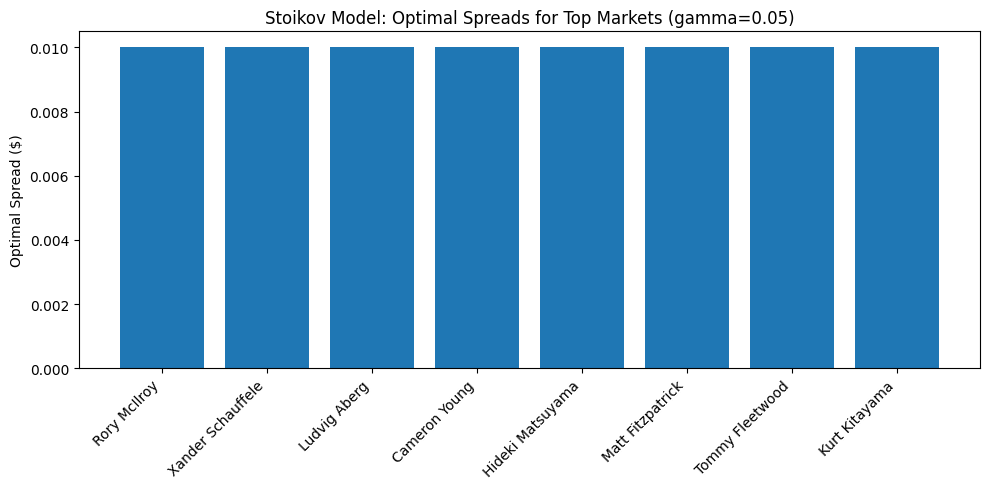


Model Configuration:
  Risk Aversion Parameter (gamma): 0.05
  Current Inventory: 0 (neutral position)

Interpretation:
  - Higher spread indicates higher volatility or stronger order flow imbalance
  - Bid price: Maximum price to bid (buy)
  - Ask price: Minimum price to ask (sell)


In [11]:
# Implement a Stoikov model to estimate optimal bid and ask prices based on the historical price data and trade volumes for the top markets. 
# This would involve calculating the expected price movement and volatility, and then using these to determine the optimal spread for placing limit orders.

import numpy as np
from scipy.optimize import fminbound

class StoikovMarketMaker:
    """
    Stoikov market-making model for optimal bid/ask quote placement.
    
    Based on: Stoikov, S. (2005). "Optimal Execution with Stochastic Demand"
    
    Key parameters:
    - gamma: Risk aversion parameter (higher = more averse to holding inventory)
    - sigma: Volatility of the asset price
    - lambda_param: Order arrival rate (trades per unit time)
    - dt: Time step for calculations
    """
    
    def __init__(self, gamma=0.01, dt=1.0):
        """
        Initialize the Stoikov model parameters.
        
        Args:
            gamma: Risk aversion coefficient (default 0.01)
            dt: Time step in seconds (default 1.0)
        """
        self.gamma = gamma
        self.dt = dt
    
    def calculate_volatility(self, price_series, window=20):
        """Calculate rolling volatility from price data."""
        returns = np.log(price_series / price_series.shift(1)).dropna()
        volatility = returns.rolling(window=window).std() * np.sqrt(252 * 252)  # Annualized
        return volatility
    
    def calculate_order_arrival_rate(self, bid_volume, ask_volume):
        """Calculate order arrival rates from bid/ask volume imbalance."""
        total_volume = bid_volume + ask_volume
        if total_volume == 0:
            return 0.5, 0.5
        lambda_ask = ask_volume / total_volume  # Rate of ask-side trades
        lambda_bid = bid_volume / total_volume  # Rate of bid-side trades
        return lambda_bid, lambda_ask
    
    def optimal_spread(self, mid_price, volatility, inventory, lambda_bid, lambda_ask):
        """
        Calculate optimal bid/ask spread using Stoikov's formula.
        
        The formula: spread = (2/gamma) * arcsinh((lambda_ask - lambda_bid) / (2 * lambda_ask * lambda_bid))
                            + (2 * gamma * sigma^2 * T / Q) * inventory
        
        where:
        - gamma: risk aversion
        - sigma: volatility
        - lambda_bid, lambda_ask: order arrival rates
        - inventory: current inventory position (negative = short, positive = long)
        """
        
        # Symmetric spread component from order flow imbalance
        try:
            if lambda_bid + lambda_ask > 0:
                order_flow_asymmetry = (lambda_ask - lambda_bid) / (2 * max(lambda_ask * lambda_bid, 0.001))
                symmetric_spread = (2 / max(self.gamma, 0.0001)) * np.arcsinh(order_flow_asymmetry)
            else:
                symmetric_spread = 0
        except:
            symmetric_spread = 0
        
        # Inventory correction component
        # Higher inventory penalty keeps market maker from accumulating risk
        inventory_correction = 2 * self.gamma * (volatility ** 2) * inventory
        
        return max(0.01, symmetric_spread + inventory_correction)  # Minimum spread of $0.01
    
    def get_quotes(self, mid_price, volatility, inventory, lambda_bid, lambda_ask):
        """
        Get optimal bid and ask prices.
        
        Returns:
            bid_price: Optimal bid price
            ask_price: Optimal ask price
        """
        spread = self.optimal_spread(mid_price, volatility, inventory, lambda_bid, lambda_ask)
        bid_price = mid_price - spread / 2
        ask_price = mid_price + spread / 2
        
        return bid_price, ask_price, spread

# Apply Stoikov model to top markets
print("\n=== STOIKOV MODEL OPTIMAL QUOTES ===\n")

# Model parameters
gamma = 0.05  # Risk aversion (adjust based on risk tolerance)
dt = 1.0

model = StoikovMarketMaker(gamma=gamma, dt=dt)

results = []

for player_name in top_markets:
    player_data = market_data[market_data['player_name'] == player_name].copy()
    player_data['created_time'] = pd.to_datetime(player_data['created_time'], unit='ms')
    player_data = player_data.sort_values('created_time')
    player_data['yes_price_dollars'] = player_data['yes_price_dollars'].astype(float)
    player_data['count_fp'] = player_data['count_fp'].astype(float)
    
    # Calculate volatility from yes price
    volatility = model.calculate_volatility(player_data['yes_price_dollars'], window=10).iloc[-1]
    
    # Current mid price (latest yes price)
    mid_price = player_data['yes_price_dollars'].iloc[-1]
    
    # Calculate order flow from bid/ask side data
    bid_volume = player_data[player_data['taker_book_side'] == 'bid']['count_fp'].sum()
    ask_volume = player_data[player_data['taker_book_side'] == 'ask']['count_fp'].sum()
    lambda_bid, lambda_ask = model.calculate_order_arrival_rate(bid_volume, ask_volume)
    
    # Estimate inventory (assume neutral at 0)
    inventory = 0
    
    # Get optimal quotes
    bid_price, ask_price, spread = model.get_quotes(mid_price, volatility, inventory, lambda_bid, lambda_ask)
    
    # Store results
    results.append({
        'Player': player_name,
        'Mid Price': f'${mid_price:.3f}',
        'Optimal Bid': f'${max(0, bid_price):.3f}',
        'Optimal Ask': f'${ask_price:.3f}',
        'Spread': f'${spread:.3f}',
        'Volatility': f'{volatility:.4f}',
        'Bid Volume': f'{bid_volume:.0f}',
        'Ask Volume': f'{ask_volume:.0f}',
        'Inventory': inventory
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Visualize spreads across top markets
plt.figure(figsize=(10, 5))
spread_values = [float(r['Spread'].replace('$', '')) for r in results]
plt.bar(range(len(results)), spread_values)
plt.xticks(range(len(results)), [r['Player'] for r in results], rotation=45, ha='right')
plt.ylabel('Optimal Spread ($)')
plt.title(f'Stoikov Model: Optimal Spreads for Top Markets (gamma={gamma})')
plt.tight_layout()
plt.show()

print(f"\nModel Configuration:")
print(f"  Risk Aversion Parameter (gamma): {gamma}")
print(f"  Current Inventory: 0 (neutral position)")
print(f"\nInterpretation:")
print(f"  - Higher spread indicates higher volatility or stronger order flow imbalance")
print(f"  - Bid price: Maximum price to bid (buy)")
print(f"  - Ask price: Minimum price to ask (sell)")
